In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data1 = pd.read_csv('CIC-IDS2017/Monday-WorkingHours.pcap_ISCX.csv')
data2 = pd.read_csv('CIC-IDS2017/Tuesday-WorkingHours.pcap_ISCX.csv')
data3 = pd.read_csv('CIC-IDS2017/Wednesday-workingHours.pcap_ISCX.csv')
data4 = pd.read_csv('CIC-IDS2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data5 = pd.read_csv('CIC-IDS2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('CIC-IDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data7 = pd.read_csv('CIC-IDS2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data8 = pd.read_csv('CIC-IDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [3]:
data_list = [data1, data2, data3, data4, data5, data6, data7, data8]

In [4]:
data = pd.concat(data_list)
rows, cols = data.shape
print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

New dimension:
Number of rows: 2830743
Number of columns: 79
Total cells: 223628697


In [5]:
for d in data_list: del d

In [6]:
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

DATA Cleaning

In [7]:
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}')

Number of duplicates: 308381


In [8]:
data.drop_duplicates(inplace = True)
data.shape

(2522362, 79)

In [9]:
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0])

Flow Bytes/s    353
dtype: int64


In [10]:
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [11]:
print(f'Initial missing values: {data.isna().sum().sum()}')
data.replace([np.inf, -np.inf], np.nan, inplace = True)
print(f'Missing values after processing infinite values: {data.isna().sum().sum()}')

Initial missing values: 353
Missing values after processing infinite values: 3128


In [12]:
missing = data.isna().sum()
print(missing.loc[missing > 0])

Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64


In [13]:
mis_per = (missing / len(data)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})
print(mis_table.loc[mis_per > 0])

                Missing Values  Percentage of Total Values
Flow Bytes/s              1564                        0.06
Flow Packets/s            1564                        0.06


In [14]:
med_flow_bytes = data['Flow Bytes/s'].median()
med_flow_packets = data['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  3715.0378579999997
Median of Flow Packets/s:  69.742244285


In [15]:
data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
data['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

C:\Users\leasa\AppData\Local\Temp\ipykernel_32328\1422842539.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
C:\Users\leasa\AppData\Local\Temp\ipykernel_32328\1422842539.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [16]:
print('Number of \'Flow Bytes/s\' missing values:', data['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', data['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


Analysing Patterns using Visualisations

In [17]:
data['Label'].unique()

array(['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'Infiltration', 'Bot', 'PortScan',
       'DDoS'], dtype=object)

In [18]:
data['Label'].value_counts()

Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Data Preprocessing

In [19]:
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

Initial memory usage: 1539.53 MB
Final memory usage: 808.25 MB


In [20]:
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Reduced memory usage: 47.50%


In [21]:
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

Applying PCA to reduce dimensions

In [22]:
from sklearn.preprocessing import StandardScaler

features = data.drop('Label', axis = 1)
attacks = data['Label']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [23]:
from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

information retained: 99.30%


In [43]:
transformed_features = ipca.transform(scaled_features)
new_data = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data['Label'] = attacks.values

In [ ]:
import pandas as pd

prep_summary = pd.DataFrame({
    'Metric': [
        'Total Rows', 
        'Number of Features', 
        'Memory Usage (MB)', 
        'Duplicate Records',
        'Null/Inf Values'
    ],
    'Raw Dataset': [
        2830743, 
        79, 
        1539.53, 
        308381, 
        3128
    ],
    'Processed Dataset': [
        len(data), 
        len(new_data.columns) - 1,
        new_memory_usage, 
        0, 
        0
    ]
})

prep_summary['Change (%)'] = ((prep_summary['Processed Dataset'] - prep_summary['Raw Dataset']) / prep_summary['Raw Dataset'] * 100).round(2)

print("Table: Data Preparation Summary Stats")
print(prep_summary.to_string(index=False))

Table: Data Preparation Summary Stats
            Metric  Raw Dataset  Processed Dataset  Change (%)
        Total Rows   2830743.00       2.522362e+06      -10.89
Number of Features        79.00       3.500000e+01      -55.70
 Memory Usage (MB)      1539.53       8.082520e+02      -47.50
 Duplicate Records    308381.00       0.000000e+00     -100.00
   Null/Inf Values      3128.00       0.000000e+00     -100.00


# Anomaly detection 

### Dataset spliting

In [ ]:
from sklearn.model_selection import train_test_split

unknown_attacks = [
    "DoS slowloris",
    "DoS Slowhttptest",
    "Bot"
]

labels = new_data["Label"]
X = new_data.drop("Label", axis=1)

known_mask = (labels == "BENIGN") | (~labels.isin(unknown_attacks))

X_known = X[known_mask]
y_known = (labels[known_mask] != "BENIGN").astype(int)

X_train_supervised, _, y_train_supervised, _ = train_test_split(
    X_known,
    y_known,
    test_size=0.2,
    random_state=42,
    stratify=y_known
)


In [26]:
labels = new_data["Label"]
X = new_data.drop("Label", axis=1)
X_benign = X[labels == "BENIGN"]
X_train_unsupervised = X_benign.sample(n=200_000, random_state=42)

In [27]:
_, X_test, _, y_test = train_test_split(
    X,
    (labels != "BENIGN").astype(int),
    test_size=0.2,
    random_state=42,
    stratify=(labels != "BENIGN").astype(int)
)

In [ ]:

X_unknown = X[labels.isin(unknown_attacks)]
y_unknown = np.ones(len(X_unknown), dtype=int)


X_benign = X[labels == "BENIGN"].sample(
    n=len(X_unknown),
    random_state=42
)
y_benign = np.zeros(len(X_benign), dtype=int)

X_test_unknown = pd.concat([X_unknown, X_benign])
y_test_unknown = np.concatenate([y_unknown, y_benign])


### Unsupervised methods

OneClassSVM (https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html)

class sklearn.svm.OneClassSVM(*, kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, nu=0.5, shrinking=True, cache_size=200, verbose=False, max_iter=-1)

In [29]:
from sklearn.svm import OneClassSVM
ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_train_unsupervised)

OneClassSVM(nu=0.05)

In [30]:
scores_ocsvm = -ocsvm.decision_function(X_test)  
pred_ocsvm = ocsvm.predict(X_test)
pred_ocsvm = (pred_ocsvm == -1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n=== OneClassSVM ===")
print(confusion_matrix(y_test, pred_ocsvm))
print(classification_report(y_test, pred_ocsvm))
print("ROC-AUC:", roc_auc_score(y_test, scores_ocsvm))


=== OneClassSVM ===
[[398045  21252]
 [ 35689  49487]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.93    419297
           1       0.70      0.58      0.63     85176

    accuracy                           0.89    504473
   macro avg       0.81      0.77      0.78    504473
weighted avg       0.88      0.89      0.88    504473

ROC-AUC: 0.7573428489512779


In [31]:
scores_ocsvm = -ocsvm.decision_function(X_test_unknown)  
pred_ocsvm = ocsvm.predict(X_test_unknown)
pred_ocsvm = (pred_ocsvm == -1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n=== OneClassSVM ===")
print(confusion_matrix(y_test_unknown, pred_ocsvm))
print(classification_report(y_test_unknown, pred_ocsvm))
print("ROC-AUC:", roc_auc_score(y_test_unknown, scores_ocsvm))


=== OneClassSVM ===
[[11900   666]
 [ 4796  7770]]
              precision    recall  f1-score   support

           0       0.71      0.95      0.81     12566
           1       0.92      0.62      0.74     12566

    accuracy                           0.78     25132
   macro avg       0.82      0.78      0.78     25132
weighted avg       0.82      0.78      0.78     25132

ROC-AUC: 0.8372274479875654


LocalOutlierFactor (https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html#sklearn.neighbors.LocalOutlierFactor)

class sklearn.neighbors.LocalOutlierFactor(n_neighbors=20, *, algorithm='auto', leaf_size=30, metric='minkowski', p=2, metric_params=None, contamination='auto', novelty=False, n_jobs=None)[source]


In [32]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(
    n_neighbors=80,
    leaf_size=80,
    novelty=True,
    metric='minkowski',
    p=2
)
lof.fit(X_train_unsupervised)

LocalOutlierFactor(leaf_size=80, n_neighbors=80, novelty=True)

In [33]:
scores_lof = -lof.decision_function(X_test)
pred_lof = (lof.predict(X_test) == -1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n=== Local Outlier Factor ===")
print(confusion_matrix(y_test, pred_lof))
print(classification_report(y_test, pred_lof))
print("ROC-AUC:", roc_auc_score(y_test, scores_lof))

c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



=== Local Outlier Factor ===
[[355966  63331]
 [ 13270  71906]]
              precision    recall  f1-score   support

           0       0.96      0.85      0.90    419297
           1       0.53      0.84      0.65     85176

    accuracy                           0.85    504473
   macro avg       0.75      0.85      0.78    504473
weighted avg       0.89      0.85      0.86    504473

ROC-AUC: 0.8877557905035284


In [34]:
scores_lof = -lof.decision_function(X_test_unknown)
pred_lof = (lof.predict(X_test_unknown) == -1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n=== Local Outlier Factor ===")
print(confusion_matrix(y_test_unknown, pred_lof))
print(classification_report(y_test_unknown, pred_lof))
print("ROC-AUC:", roc_auc_score(y_test_unknown, scores_lof))

c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



=== Local Outlier Factor ===
[[10716  1850]
 [ 7458  5108]]
              precision    recall  f1-score   support

           0       0.59      0.85      0.70     12566
           1       0.73      0.41      0.52     12566

    accuracy                           0.63     25132
   macro avg       0.66      0.63      0.61     25132
weighted avg       0.66      0.63      0.61     25132

ROC-AUC: 0.7015433918745092


### Supervised method

Multi-layer Perceptron(https://scikit-learn.org/stable/modules/neural_networks_supervised.html)

In [35]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=100,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5
)

mlp.fit(X_train_supervised, y_train_supervised)

MLPClassifier(batch_size=256, early_stopping=True, hidden_layer_sizes=(100, 50),
              max_iter=100, n_iter_no_change=5, random_state=42)

In [36]:
from sklearn.metrics import  classification_report,confusion_matrix,roc_auc_score

y_pred = mlp.predict(X_test)
y_score = mlp.predict_proba(X_test)[:, 1]

print("=== MLP Classifier ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

=== MLP Classifier ===
[[418747    550]
 [  2924  82252]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    419297
           1       0.99      0.97      0.98     85176

    accuracy                           0.99    504473
   macro avg       0.99      0.98      0.99    504473
weighted avg       0.99      0.99      0.99    504473

ROC-AUC: 0.993666874331656


In [37]:
from sklearn.metrics import  classification_report,confusion_matrix,roc_auc_score

y_pred = mlp.predict(X_test_unknown)
y_score = mlp.predict_proba(X_test_unknown)[:, 1]

print("=== MLP Classifier ===")
print(confusion_matrix(y_test_unknown, y_pred))
print(classification_report(y_test_unknown, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_unknown, y_score))

=== MLP Classifier ===
[[12540    26]
 [10665  1901]]
              precision    recall  f1-score   support

           0       0.54      1.00      0.70     12566
           1       0.99      0.15      0.26     12566

    accuracy                           0.57     25132
   macro avg       0.76      0.57      0.48     25132
weighted avg       0.76      0.57      0.48     25132

ROC-AUC: 0.7899087818704634


c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


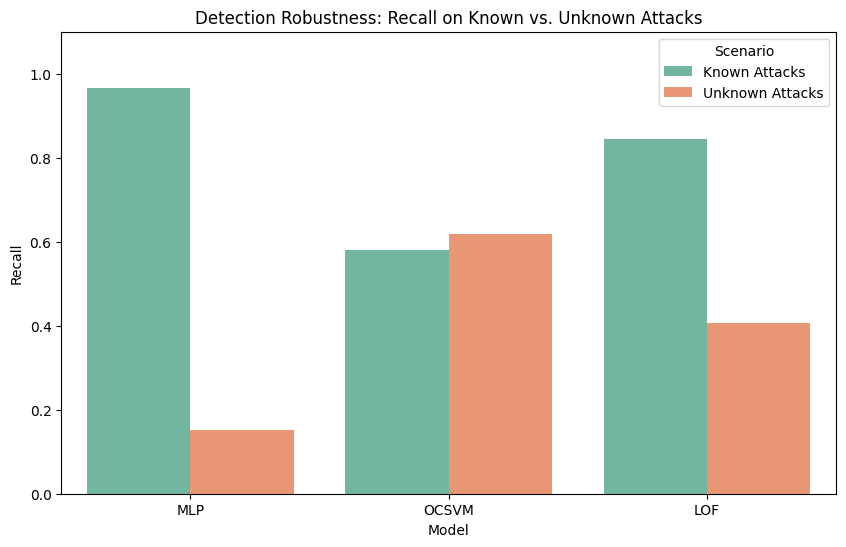

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score

def get_metrics(model, X, y, is_unsupervised=False):
    if is_unsupervised:
        preds = (model.predict(X) == -1).astype(int)
    else:
        preds = model.predict(X)
    return recall_score(y, preds), f1_score(y, preds)

m_recall, m_f1 = get_metrics(mlp, X_test, y_test)
mu_recall, mu_f1 = get_metrics(mlp, X_test_unknown, y_test_unknown)

o_recall, o_f1 = get_metrics(ocsvm, X_test, y_test, True)
ou_recall, ou_f1 = get_metrics(ocsvm, X_test_unknown, y_test_unknown, True)

l_recall, l_f1 = get_metrics(lof, X_test, y_test, True)
lu_recall, lu_f1 = get_metrics(lof, X_test_unknown, y_test_unknown, True)

results_data = {
    'Model': ['MLP', 'MLP', 'OCSVM', 'OCSVM', 'LOF', 'LOF'],
    'Scenario': ['Known Attacks', 'Unknown Attacks'] * 3,
    'Recall': [m_recall, mu_recall, o_recall, ou_recall, l_recall, lu_recall],
    'F1-Score': [m_f1, mu_f1, o_f1, ou_f1, l_f1, lu_f1]
}
df_viz = pd.DataFrame(results_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_viz, x='Model', y='Recall', hue='Scenario', palette='Set2')
plt.title('Detection Robustness: Recall on Known vs. Unknown Attacks')
plt.ylim(0, 1.1)
plt.show()

c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


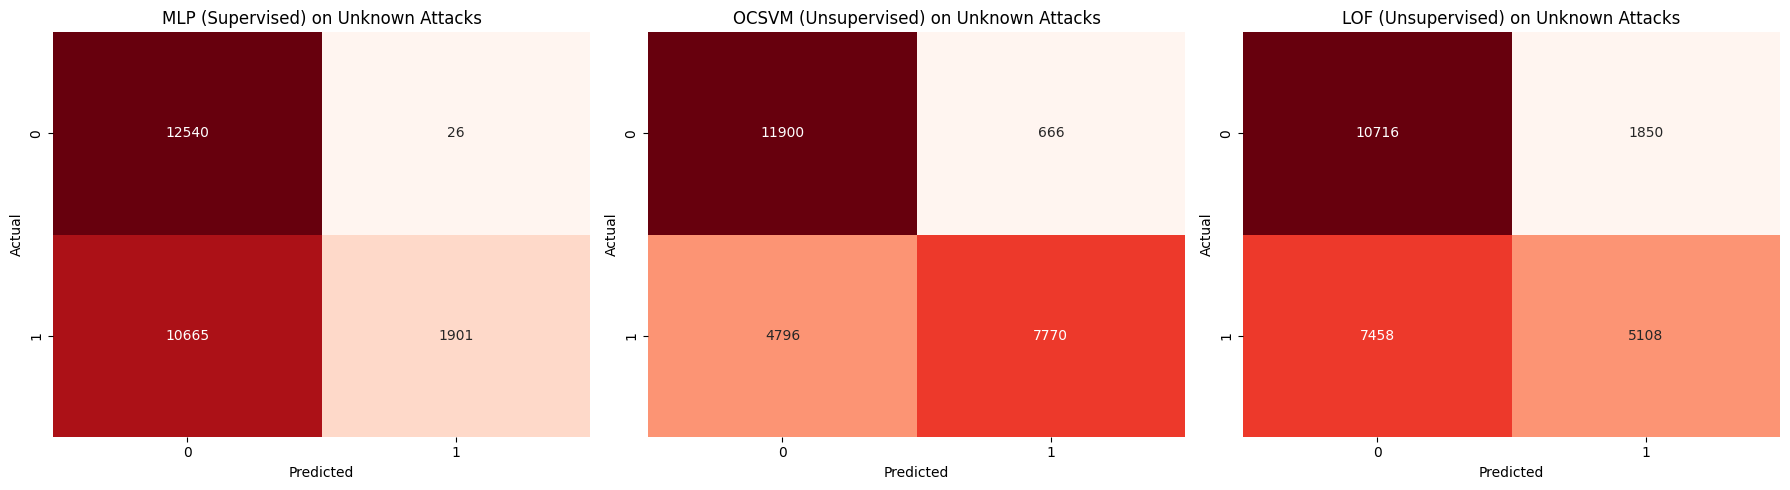

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (mlp, "MLP (Supervised)", False),
    (ocsvm, "OCSVM (Unsupervised)", True),
    (lof, "LOF (Unsupervised)", True)
]

for i, (model, name, is_unsup) in enumerate(models):
    if is_unsup:
        y_pred = (model.predict(X_test_unknown) == -1).astype(int)
    else:
        y_pred = model.predict(X_test_unknown)
    
    cm = confusion_matrix(y_test_unknown, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Reds', cbar=False)
    axes[i].set_title(f'{name} on Unknown Attacks')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

c:\Users\leasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


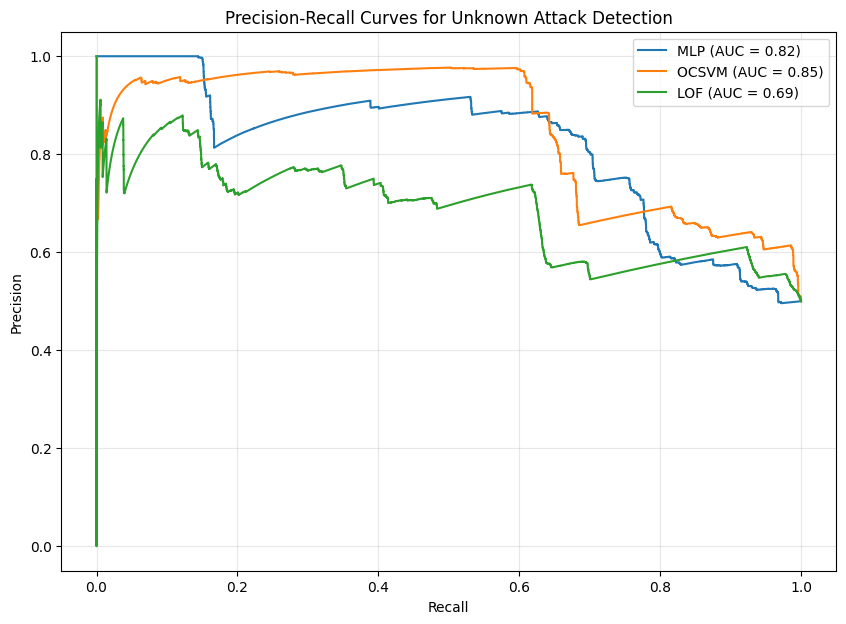

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(10, 7))

# MLP
y_scores_mlp = mlp.predict_proba(X_test_unknown)[:, 1]
p, r, _ = precision_recall_curve(y_test_unknown, y_scores_mlp)
plt.plot(r, p, label=f'MLP (AUC = {auc(r, p):.2f})')

# OCSVM
y_scores_ocsvm = -ocsvm.decision_function(X_test_unknown)
p, r, _ = precision_recall_curve(y_test_unknown, y_scores_ocsvm)
plt.plot(r, p, label=f'OCSVM (AUC = {auc(r, p):.2f})')

# LOF
y_scores_lof = -lof.decision_function(X_test_unknown)
p, r, _ = precision_recall_curve(y_test_unknown, y_scores_lof)
plt.plot(r, p, label=f'LOF (AUC = {auc(r, p):.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Unknown Attack Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()